In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Freight Rate Prediction

In [13]:
df = pd.read_csv("train-test.csv")

print("Shape:", df.shape)
display(df.head())
df.info()


Shape: (48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [14]:
print("Duplicate rows:", df.duplicated().sum())

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
})

display(summary)

Duplicate rows: 0


,dtype,missing_count,missing_pct,n_unique
load_id,object,0,0.00,48000
pickup,object,0,0.00,64
delivery,object,0,0.00,64
pickup_lat,float64,0,0.00,64
pickup_lon,float64,0,0.00,63
delivery_lat,float64,0,0.00,64
delivery_lon,float64,0,0.00,63
distance,float64,0,0.00,21204
equipment,object,0,0.00,3
weight,float64,300,0.62,23678


In [15]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-047984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


In [16]:
# Correct invalid negative weight values
df["weight"] = df["weight"].abs()

In [17]:
# Inspecting central tendencies and distributions of weight across equipment types
# to decide whether to impute missing values using overall mean/median or group-level medians.
print(df['weight'].median())
print(df['weight'].mean())
print(df['weight'].mode())
print(df['weight'].min())
print(df['weight'].max())
print(df.groupby('equipment')['weight'].mean())
print(df.groupby('equipment')['weight'].median())

31496.0
31417.24924528302
0    47500.0
Name: weight, dtype: float64
5000.0
47500.0
equipment
Dry Van    31389.812928
Flatbed    31480.436307
Reefer     31433.275992
Name: weight, dtype: float64
equipment
Dry Van    31444.0
Flatbed    31532.5
Reefer     31577.0
Name: weight, dtype: float64


## Market Index Exploration

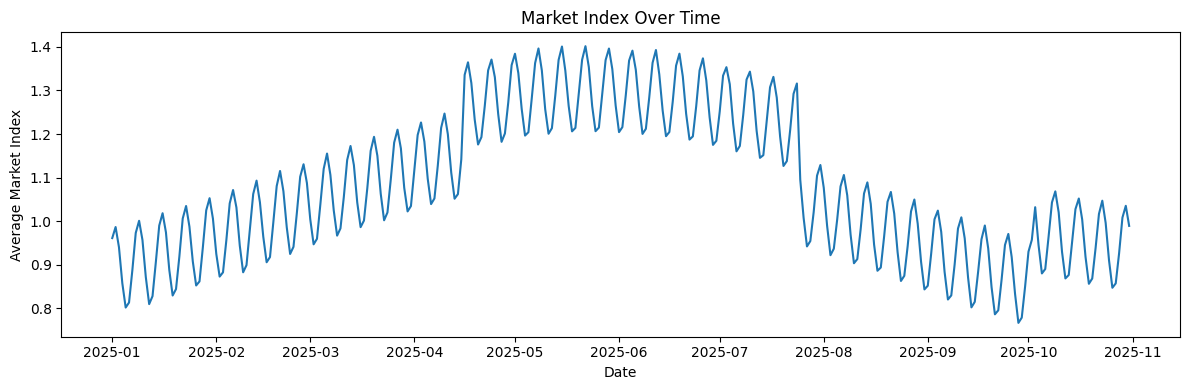

In [18]:
# Market index exploration
df["date"] = pd.to_datetime(df["date"])

market_trend = (
    df.groupby("date")["market_index"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 4))
plt.plot(market_trend["date"], market_trend["market_index"])
plt.title("Market Index Over Time")
plt.xlabel("Date")
plt.ylabel("Average Market Index")
plt.tight_layout()
plt.show()

The market index shows temporal variation, so missing values will later be imputed using time-based statistics learned from the training split only.

,count,mean,median,std
equipment,,,,
Dry Van,27000,1.0837,1.0558,0.1678
Flatbed,8680,1.0828,1.0554,0.1687
Reefer,11946,1.0832,1.0560,0.1683


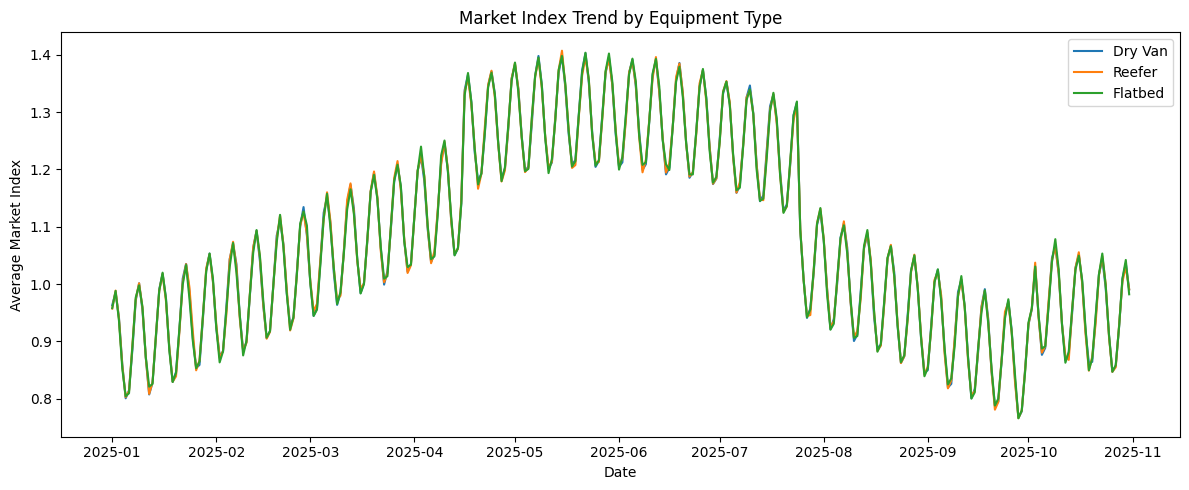

In [19]:
# Market index by equipment type
market_by_equipment = (
    df.groupby("equipment")["market_index"]
      .agg(["count", "mean", "median", "std"])
      .round(4)
)

display(market_by_equipment)

plt.figure(figsize=(12, 5))

for equipment in df["equipment"].dropna().unique():
    equipment_trend = (
        df[df["equipment"] == equipment]
        .groupby("date")["market_index"]
        .mean()
    )

    plt.plot(
        equipment_trend.index,
        equipment_trend.values,
        label=equipment
    )

plt.title("Market Index Trend by Equipment Type")
plt.xlabel("Date")
plt.ylabel("Average Market Index")
plt.legend()
plt.tight_layout()
plt.show()

### Market Index Imputation Strategy

Market index varies over time but behaves similarly across equipment types.  
Missing values will therefore be imputed using monthly medians computed from the training split only.

### Geospatial Sanity Check

Pickup points inside US: 100.00%
Delivery points inside US: 100.00%


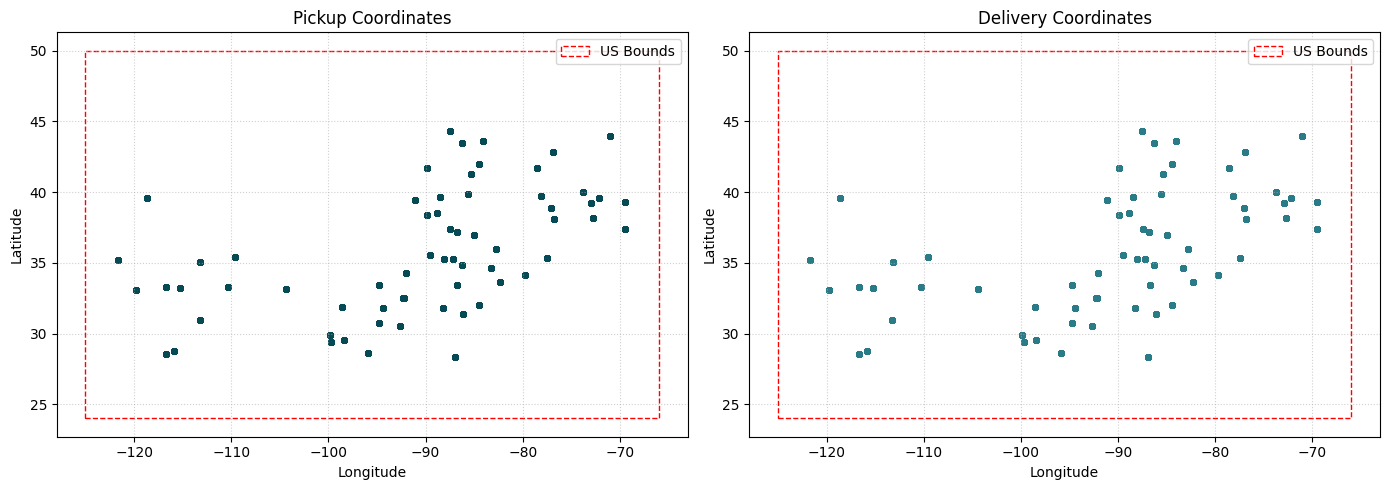

In [20]:
import matplotlib.patches as patches

# Contiguous US bounds
lat_min, lat_max = 24.0, 50.0
lon_min, lon_max = -125.0, -66.0

# Check percentage of valid points
pickup_valid = df["pickup_lat"].between(lat_min, lat_max) & df[
    "pickup_lon"
].between(lon_min, lon_max)
delivery_valid = df["delivery_lat"].between(lat_min, lat_max) & df[
    "delivery_lon"
].between(lon_min, lon_max)

print(f"Pickup points inside US: {pickup_valid.mean() * 100:.2f}%")
print(f"Delivery points inside US: {delivery_valid.mean() * 100:.2f}%")

# Plot coordinates with bounding box
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pickups
axes[0].scatter(
    df["pickup_lon"],
    df["pickup_lat"],
    alpha=0.2,
    s=15,
    color="#064A56",
)
axes[0].add_patch(
    patches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        fill=False,
        edgecolor="red",
        linestyle="--",
        label="US Bounds",
    )
)
axes[0].set_title("Pickup Coordinates")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

# Deliveries
axes[1].scatter(
    df["delivery_lon"],
    df["delivery_lat"],
    alpha=0.2,
    s=15,
    color="#2A7B88",
)
axes[1].add_patch(
    patches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        fill=False,
        edgecolor="red",
        linestyle="--",
        label="US Bounds",
    )
)
axes[1].set_title("Delivery Coordinates")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

All pickup and delivery coordinates fall within the expected contiguous US bounds.

###  Outlier Inspection




      column     min  lower_whisker       q1   median       q3  upper_whisker      max      iqr  outliers_count outliers_pct
    distance   70.00       -1092.29   550.40   953.30  1645.52        3288.21  3439.80  1095.12              32        0.07%
      weight 5000.00        9210.12 25922.00 31496.00 37063.25       53775.12 47500.00 11141.25             149        0.31%
market_index    0.68           0.54     0.95     1.06     1.22           1.62     1.47     0.27               0        0.00%
quote_signal    0.69           1.40     1.89     2.06     2.22           2.72     3.61     0.33            1956        4.08%
 posted_rate   57.22       -1867.24  1251.55  2030.76  3330.75        6449.54 25533.00  2079.20             260        0.54%


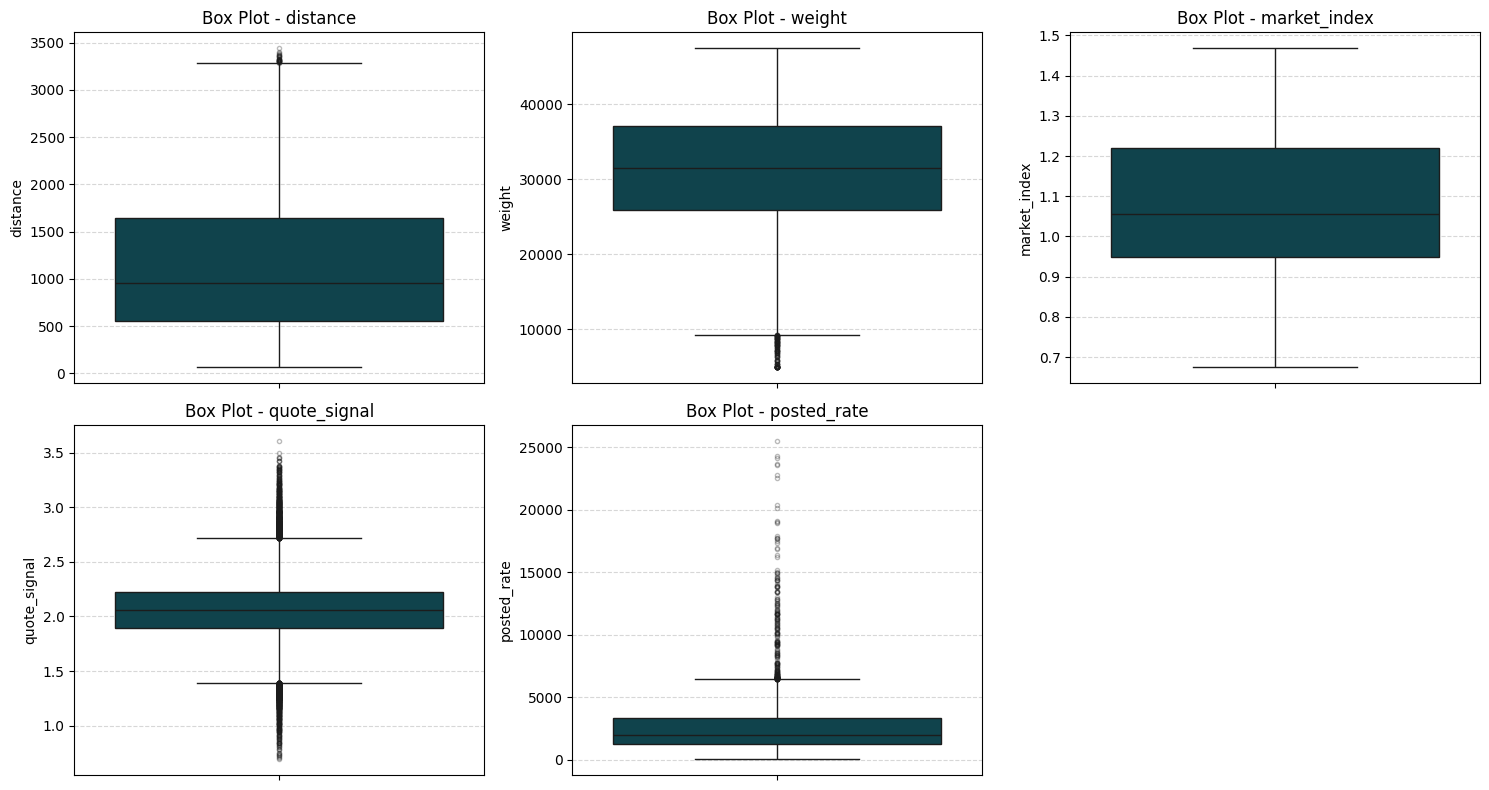

In [21]:

# Select non-geographic numerical features
geo_cols = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]
operational_cols = [
    col
    for col in df.select_dtypes(include=[np.number]).columns
    if col not in geo_cols and col not in ["load_id", "id"]
]

# Calculate IQR bounds and outlier counts
stats_list = []
for col in operational_cols:
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outliers.sum()
    outliers_pct = (outliers_count / len(df)) * 100

    stats_list.append(
        {
            "column": col,
            "min": round(df[col].min(), 2),
            "lower_whisker": round(lower_bound, 2),
            "q1": round(q1, 2),
            "median": round(median, 2),
            "q3": round(q3, 2),
            "upper_whisker": round(upper_bound, 2),
            "max": round(df[col].max(), 2),
            "iqr": round(iqr, 2),
            "outliers_count": outliers_count,
            "outliers_pct": f"{outliers_pct:.2f}%",
        }
    )

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

# Plot boxplots
n_cols = 3
n_rows = math.ceil(len(operational_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(operational_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color="#064A56",
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.3},
    )
    axes[i].set_title(f"Box Plot - {col}")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outlier Inspection

The IQR analysis identifies relatively few extreme observations in most variables.  
`quote_signal` shows the largest proportion of statistical outliers (~4%), while `posted_rate`, `distance`, and `weight` contain only a small fraction of extreme values.

These observations are retained because they may represent valid freight-market behavior rather than data-entry errors.

,skewness
posted_rate,1.902395
distance,0.765775
market_index,0.214263
quote_signal,0.171989
weight,-0.128318


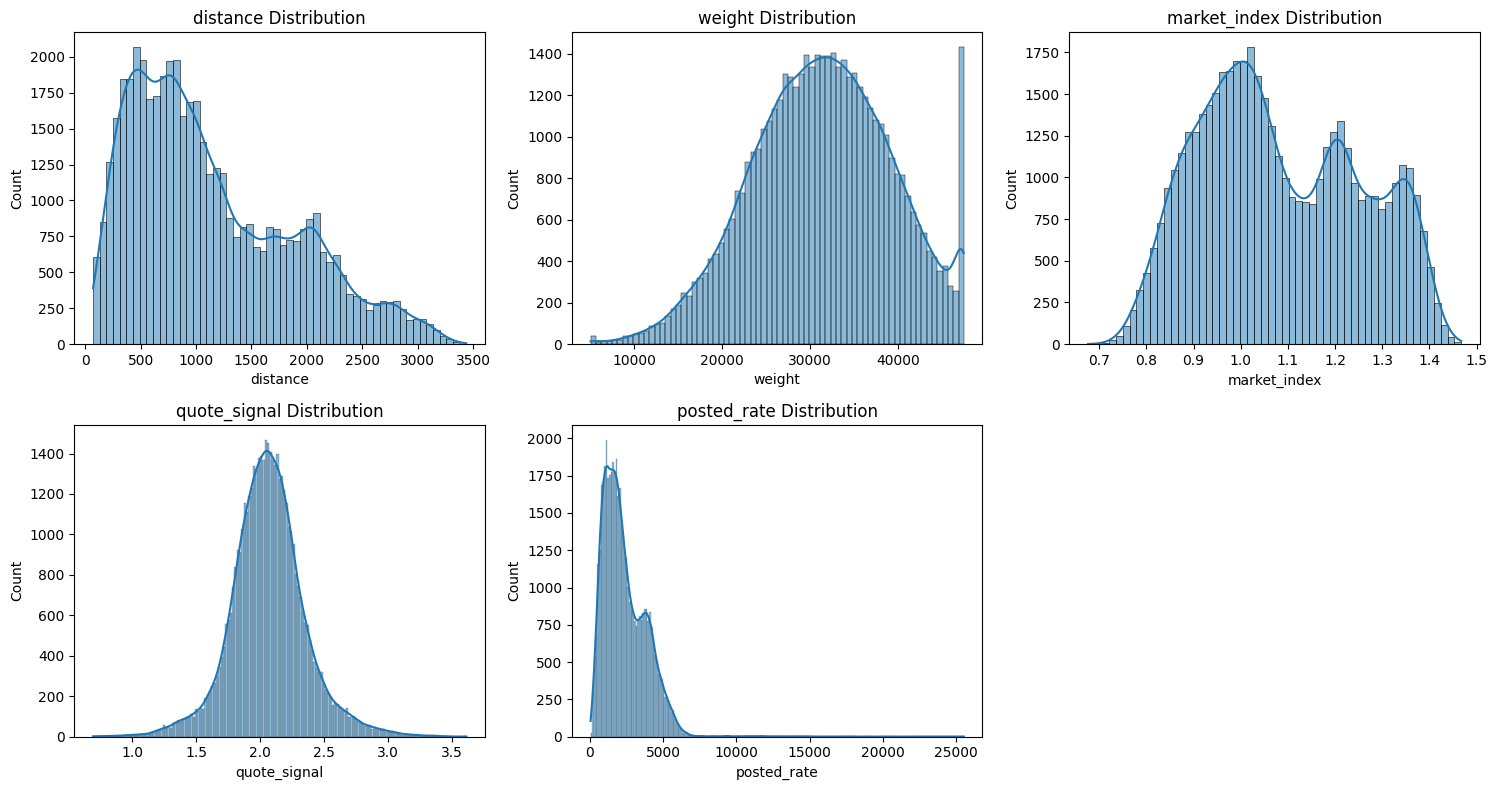

In [22]:
# Skewness inspection
features_to_inspect = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

skewness = (
    df[features_to_inspect]
    .skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)

display(skewness)

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_inspect):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)

# Remove unused subplot
for j in range(len(features_to_inspect), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

`posted_rate` exhibits a strong positive skew (1.90), while the remaining predictors are relatively balanced.  
Because the target has a pronounced right tail, a log transformation will be evaluated to reduce skewness and potentially improve regression performance.

Original skewness: 1.902
Log-transformed skewness: -0.489


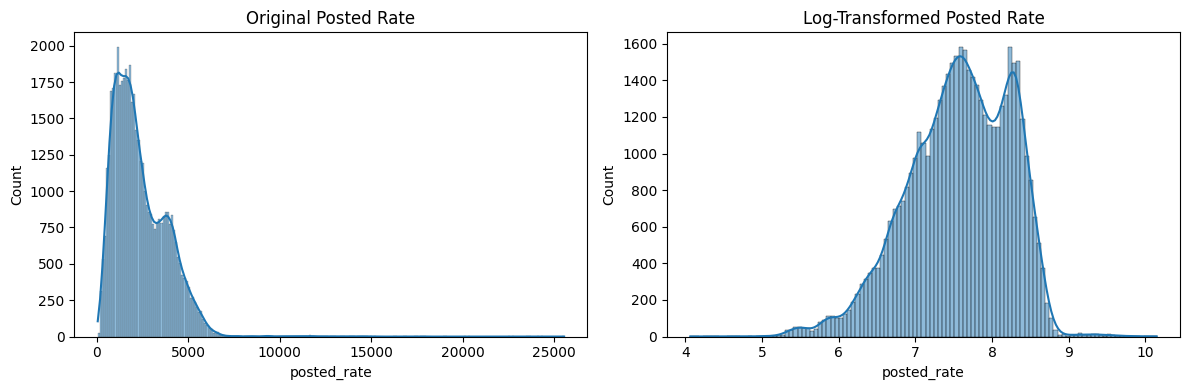

In [23]:
target_raw = df["posted_rate"]
target_log = np.log1p(target_raw)

print(f"Original skewness: {target_raw.skew():.3f}")
print(f"Log-transformed skewness: {target_log.skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(target_raw, kde=True, ax=axes[0])
axes[0].set_title("Original Posted Rate")

sns.histplot(target_log, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Posted Rate")

plt.tight_layout()
plt.show()

The `log1p` transformation substantially reduces target skewness from 1.902 to -0.489.  
Both raw and log-transformed targets will be compared during model validation, and the better-performing approach will be selected.

## Feature Engineering

In [24]:
df["estimated_base_cost"] = df["distance"] * df["quote_signal"]
df["market_adjusted_cost"] = df["estimated_base_cost"] * df["market_index"]
df["weight_distance_k"] = (df["weight"] * df["distance"]) / 1000
df["adjusted_rpm"] = df["quote_signal"] * df["market_index"]

Cost interaction features combine distance, quote signal, market conditions, and load weight to test whether these relationships add predictive value.

In [25]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


df["haversine_distance"] = haversine_np(
    df["pickup_lat"],
    df["pickup_lon"],
    df["delivery_lat"],
    df["delivery_lon"]
)

df["route_circuity"] = (
    df["distance"] / (df["haversine_distance"] + 1e-5)
)

`haversine_distance` captures straight-line distance, while `route_circuity` measures how indirect the road route is relative to the straight-line path.

In [26]:
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

Date-derived features are included to capture possible monthly and weekly freight patterns.

In [27]:
candidate_features = [
    "distance",
    "weight",
    "quote_signal",
    "market_index",
    "estimated_base_cost",
    "market_adjusted_cost",
    "weight_distance_k",
    "adjusted_rpm",
    "haversine_distance",
    "route_circuity",
    "month",
    "day_of_week",
    "quarter",
    "is_weekend",
]

corr_matrix = df[candidate_features + ["posted_rate"]].corr()

target_corr = (
    corr_matrix["posted_rate"]
    .drop("posted_rate")
    .sort_values(key=abs, ascending=False)
)

display(target_corr.to_frame("correlation"))


,correlation
distance,0.908519
haversine_distance,0.908203
estimated_base_cost,0.898688
market_adjusted_cost,0.866532
weight_distance_k,0.840668
route_circuity,-0.187874
weight,0.041343
quote_signal,-0.039858
market_index,0.034165
month,0.023804


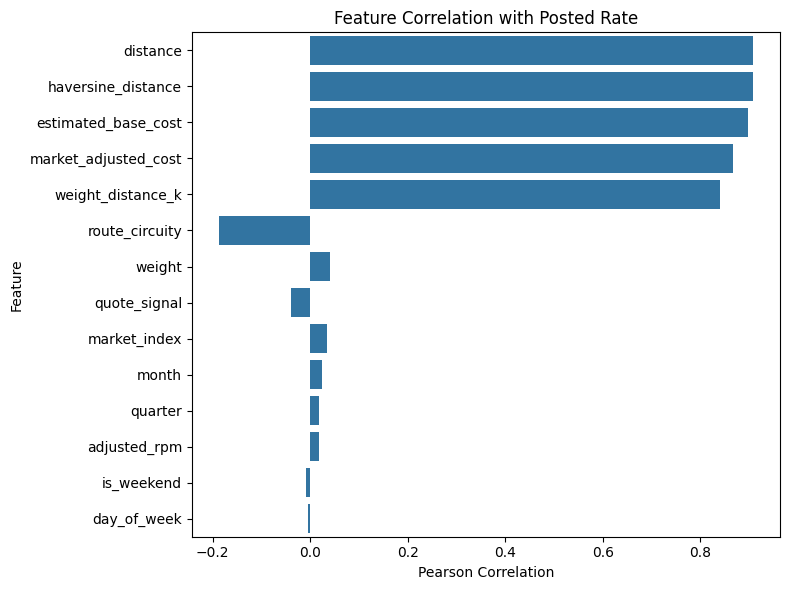

In [28]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)
plt.title("Feature Correlation with Posted Rate")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

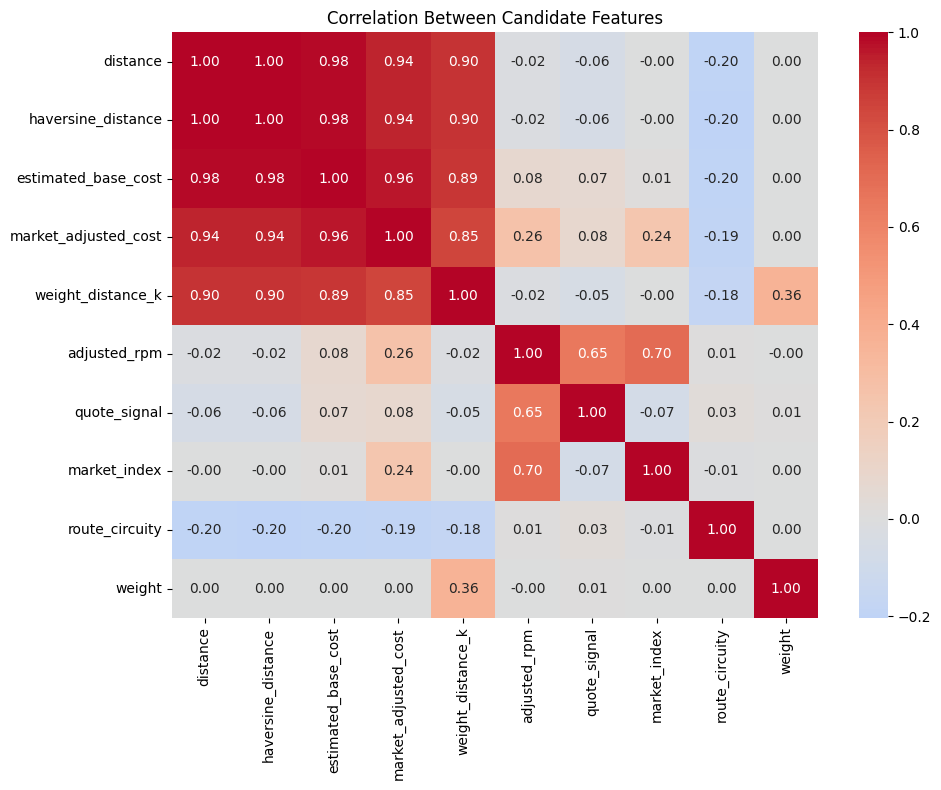

In [29]:
redundancy_features = [
    "distance",
    "haversine_distance",
    "estimated_base_cost",
    "market_adjusted_cost",
    "weight_distance_k",
    "adjusted_rpm",
    "quote_signal",
    "market_index",
    "route_circuity",
    "weight"
]

feature_corr = df[redundancy_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Candidate Features")
plt.tight_layout()
plt.show()

Several engineered features are highly correlated with `distance`, particularly
`haversine_distance`, `estimated_base_cost`, `market_adjusted_cost`, and
`weight_distance_k`.

Rather than retaining or removing features solely based on correlation,
redundant feature groups will be evaluated using validation performance.

## Chronological Train / Validation Split

In [30]:
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())

monthly_counts = (
    df.groupby(df["date"].dt.to_period("M"))
      .size()
      .to_frame("rows")
)

display(monthly_counts)

Min date: 2025-01-01 00:00:00
Max date: 2025-10-31 00:00:00


,rows
date,
2025-01,4918
2025-02,4337
2025-03,5036
2025-04,4819
2025-05,4913
2025-06,4783
2025-07,4912
2025-08,4759
2025-09,4670


In [31]:
cutoff_date = pd.Timestamp("2025-09-01")

train_df = df[df["date"] < cutoff_date].copy()
val_df = df[df["date"] >= cutoff_date].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTrain date range:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation date range:")
print(val_df["date"].min(), "to", val_df["date"].max())

Train shape: (38477, 24)
Validation shape: (9523, 24)

Train date range:
2025-01-01 00:00:00 to 2025-08-31 00:00:00

Validation date range:
2025-09-01 00:00:00 to 2025-10-31 00:00:00


A chronological split is used to better reflect the real inference setting, where the model is trained on historical data and evaluated on later unseen periods.

In [32]:
# Separate features and target
X_train = train_df.drop(columns=["posted_rate", "load_id", "target_log"], errors="ignore")
y_train = train_df["posted_rate"].copy()

X_val = val_df.drop(columns=["posted_rate", "load_id", "target_log"], errors="ignore")
y_val = val_df["posted_rate"].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (38477, 22)
X_val: (9523, 22)
y_train: (38477,)
y_val: (9523,)


In [33]:
# ---- Weight imputation learned from training data ----
weight_medians = X_train.groupby("equipment")["weight"].median()
global_weight_median = X_train["weight"].median()

def impute_weight(data):
    data = data.copy()

    missing_weight = data["weight"].isna()

    data.loc[missing_weight, "weight"] = (
        data.loc[missing_weight, "equipment"]
        .map(weight_medians)
        .fillna(global_weight_median)
    )

    return data


# ---- Market index imputation learned from training data ----
market_month_medians = (
    X_train.groupby(X_train["date"].dt.month)["market_index"]
    .median()
)

global_market_median = X_train["market_index"].median()

def impute_market_index(data):
    data = data.copy()

    missing_market = data["market_index"].isna()

    monthly_values = (
        data.loc[missing_market, "date"]
        .dt.month
        .map(market_month_medians)
        .fillna(global_market_median)
    )

    data.loc[missing_market, "market_index"] = monthly_values

    return data

## Training-Only Preprocessing

In [34]:
X_train = impute_weight(X_train)
X_val = impute_weight(X_val)

X_train = impute_market_index(X_train)
X_val = impute_market_index(X_val)

print("Train missing values:")
display(X_train.isna().sum()[X_train.isna().sum() > 0])

print("Validation missing values:")
display(X_val.isna().sum()[X_val.isna().sum() > 0])

Train missing values:


,0
market_adjusted_cost,301
weight_distance_k,235
adjusted_rpm,301


Validation missing values:


,0
market_adjusted_cost,73
weight_distance_k,65
adjusted_rpm,73


In [35]:
for data in [X_train, X_val]:
    data["estimated_base_cost"] = (
        data["distance"] * data["quote_signal"]
    )

    data["market_adjusted_cost"] = (
        data["estimated_base_cost"] * data["market_index"]
    )

    data["weight_distance_k"] = (
        data["weight"] * data["distance"]
    ) / 1000

    data["adjusted_rpm"] = (
        data["quote_signal"] * data["market_index"]
    )

Derived features that depend on imputed inputs are recalculated after training-only imputation to keep the modeling workflow leakage-safe.

In [36]:
print("Train missing values:")
display(X_train.isna().sum()[X_train.isna().sum() > 0])

print("Validation missing values:")
display(X_val.isna().sum()[X_val.isna().sum() > 0])

Train missing values:


,0


Validation missing values:


,0


## Baseline and Model Comparison

In [37]:
base_features = [
    "distance",
    "weight",
    "quote_signal",
    "market_index",
    "equipment",
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "month",
    "day_of_week",
    "quarter",
    "is_weekend"
]

In [38]:
engineered_features = [
    "estimated_base_cost",
    "market_adjusted_cost",
    "weight_distance_k",
    "adjusted_rpm",
    "haversine_distance",
    "route_circuity"
]

all_features = base_features + engineered_features

In [39]:
categorical_features = [
    "equipment",
    "pickup",
    "delivery"
]

numeric_base_features = [
    "distance",
    "weight",
    "quote_signal",
    "market_index",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "month",
    "day_of_week",
    "quarter",
    "is_weekend"
]

In [40]:
linear_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

linear_preprocessor = ColumnTransformer([
    ("num", linear_numeric_transformer, numeric_base_features),
    ("cat", categorical_transformer, categorical_features)
])

In [41]:
tree_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

tree_preprocessor = ColumnTransformer([
    ("num", tree_numeric_transformer, numeric_base_features),
    ("cat", categorical_transformer, categorical_features)
])

In [42]:
dummy_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_pipeline.fit(
    X_train[base_features],
    y_train
)

dummy_pred = dummy_pipeline.predict(
    X_val[base_features]
)

In [43]:
dummy_mae = mean_absolute_error(y_val, dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_val, dummy_pred))
dummy_mape = mean_absolute_percentage_error(y_val, dummy_pred) * 100
dummy_r2 = r2_score(y_val, dummy_pred)

print("Dummy Regressor")
print("----------------")
print(f"MAE:  ${dummy_mae:,.2f}")
print(f"RMSE: ${dummy_rmse:,.2f}")
print(f"MAPE: {dummy_mape:.2f}%")
print(f"R²:   {dummy_r2:.4f}")

Dummy Regressor
----------------
MAE:  $1,178.80
RMSE: $1,526.23
MAPE: 83.43%
R²:   -0.0002


In [44]:
linear_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(
    X_train[base_features],
    y_train
)

linear_pred = linear_pipeline.predict(
    X_val[base_features]
)

In [45]:
linear_mae = mean_absolute_error(y_val, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_val, linear_pred))
linear_mape = mean_absolute_percentage_error(y_val, linear_pred) * 100
linear_r2 = r2_score(y_val, linear_pred)

print("Linear Regression")
print("-----------------")
print(f"MAE:  ${linear_mae:,.2f}")
print(f"RMSE: ${linear_rmse:,.2f}")
print(f"MAPE: {linear_mape:.2f}%")
print(f"R²:   {linear_r2:.4f}")

Linear Regression
-----------------
MAE:  $142.54
RMSE: $638.08
MAPE: 8.10%
R²:   0.8252


In [46]:
ridge_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(
    X_train[base_features],
    y_train
)

ridge_pred = ridge_pipeline.predict(
    X_val[base_features]
)

In [47]:
ridge_mae = mean_absolute_error(y_val, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
ridge_mape = mean_absolute_percentage_error(y_val, ridge_pred) * 100
ridge_r2 = r2_score(y_val, ridge_pred)

print("Ridge Regression")
print("----------------")
print(f"MAE:  ${ridge_mae:,.2f}")
print(f"RMSE: ${ridge_rmse:,.2f}")
print(f"MAPE: {ridge_mape:.2f}%")
print(f"R²:   {ridge_r2:.4f}")

Ridge Regression
----------------
MAE:  $142.53
RMSE: $638.08
MAPE: 8.10%
R²:   0.8252


In [48]:
dt_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

dt_pipeline.fit(
    X_train[base_features],
    y_train
)

dt_pred = dt_pipeline.predict(
    X_val[base_features]
)

In [49]:
dt_mae = mean_absolute_error(y_val, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_val, dt_pred))
dt_mape = mean_absolute_percentage_error(y_val, dt_pred) * 100
dt_r2 = r2_score(y_val, dt_pred)

dt_train_pred = dt_pipeline.predict(
    X_train[base_features]
)

dt_train_r2 = r2_score(y_train, dt_train_pred)

print("Decision Tree")
print("-------------")
print(f"MAE:  ${dt_mae:,.2f}")
print(f"RMSE: ${dt_rmse:,.2f}")
print(f"MAPE: {dt_mape:.2f}%")
print(f"Train R²:      {dt_train_r2:.4f}")
print(f"Validation R²: {dt_r2:.4f}")

Decision Tree
-------------
MAE:  $171.93
RMSE: $669.61
MAPE: 7.62%
Train R²:      0.8704
Validation R²: 0.8075


In [50]:
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(
    X_train[base_features],
    y_train
)

rf_pred = rf_pipeline.predict(
    X_val[base_features]
)

In [51]:
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_mape = mean_absolute_percentage_error(y_val, rf_pred) * 100
rf_r2 = r2_score(y_val, rf_pred)

rf_train_pred = rf_pipeline.predict(
    X_train[base_features]
)

rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Random Forest")
print("-------------")
print(f"MAE:  ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"MAPE: {rf_mape:.2f}%")
print(f"Train R²:      {rf_train_r2:.4f}")
print(f"Validation R²: {rf_r2:.4f}")

Random Forest
-------------
MAE:  $314.06
RMSE: $717.02
MAPE: 24.32%
Train R²:      0.8297
Validation R²: 0.7792


Ridge provides the strongest initial MAE/RMSE performance, while XGBoost remains competitive and achieves lower percentage error. Both are retained for further feature and target-transformation experiments.

## Feature Set Comparison

In [52]:
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(
    X_train[base_features],
    y_train
)

xgb_pred = xgb_pipeline.predict(
    X_val[base_features]
)

In [53]:
xgb_mae = mean_absolute_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_val, xgb_pred) * 100
xgb_r2 = r2_score(y_val, xgb_pred)

xgb_train_pred = xgb_pipeline.predict(
    X_train[base_features]
)

xgb_train_r2 = r2_score(y_train, xgb_train_pred)

print("XGBoost")
print("-------")
print(f"MAE:  ${xgb_mae:,.2f}")
print(f"RMSE: ${xgb_rmse:,.2f}")
print(f"MAPE: {xgb_mape:.2f}%")
print(f"Train R²:      {xgb_train_r2:.4f}")
print(f"Validation R²: {xgb_r2:.4f}")

XGBoost
-------
MAE:  $147.53
RMSE: $652.63
MAPE: 7.01%
Train R²:      0.9313
Validation R²: 0.8171


In [54]:
model_results = pd.DataFrame({
    "Model": [
        "Dummy",
        "Linear Regression",
        "Ridge",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        dummy_mae,
        linear_mae,
        ridge_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        dummy_rmse,
        linear_rmse,
        ridge_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        dummy_mape,
        linear_mape,
        ridge_mape,
        dt_mape,
        rf_mape,
        xgb_mape
    ],

    "R²": [
        dummy_r2,
        linear_r2,
        ridge_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

model_results = model_results.sort_values("MAE")

display(model_results)

,Model,MAE,RMSE,MAPE (%),R²
2,Ridge,142.527633,638.075843,8.102372,0.825174
1,Linear Regression,142.543118,638.080538,8.103759,0.825172
5,XGBoost,147.528435,652.630226,7.008395,0.817108
3,Decision Tree,171.927198,669.608278,7.618127,0.807468
4,Random Forest,314.058105,717.018614,24.321206,0.779239
0,Dummy,1178.803281,1526.226298,83.426668,-0.000228


In [55]:
numeric_all_features = numeric_base_features + engineered_features

In [56]:
linear_preprocessor_all = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_all_features
    ),

    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

In [57]:
tree_preprocessor_all = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        numeric_all_features
    ),

    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

In [58]:
ridge_engineered_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor_all),
    ("model", Ridge(alpha=1.0))
])

ridge_engineered_pipeline.fit(
    X_train[all_features],
    y_train
)

ridge_engineered_pred = ridge_engineered_pipeline.predict(
    X_val[all_features]
)

In [59]:
ridge_eng_mae = mean_absolute_error(
    y_val,
    ridge_engineered_pred
)

ridge_eng_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_engineered_pred
    )
)

ridge_eng_mape = (
    mean_absolute_percentage_error(
        y_val,
        ridge_engineered_pred
    ) * 100
)

ridge_eng_r2 = r2_score(
    y_val,
    ridge_engineered_pred
)

print("Ridge + Engineered Features")
print("---------------------------")
print(f"MAE:  ${ridge_eng_mae:,.2f}")
print(f"RMSE: ${ridge_eng_rmse:,.2f}")
print(f"MAPE: {ridge_eng_mape:.2f}%")
print(f"R²:   {ridge_eng_r2:.4f}")

Ridge + Engineered Features
---------------------------
MAE:  $144.40
RMSE: $639.80
MAPE: 8.49%
R²:   0.8242


In [60]:
xgb_engineered_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor_all),

    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_engineered_pipeline.fit(
    X_train[all_features],
    y_train
)

xgb_engineered_pred = xgb_engineered_pipeline.predict(
    X_val[all_features]
)

In [61]:
xgb_eng_mae = mean_absolute_error(
    y_val,
    xgb_engineered_pred
)

xgb_eng_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_engineered_pred
    )
)

xgb_eng_mape = (
    mean_absolute_percentage_error(
        y_val,
        xgb_engineered_pred
    ) * 100
)

xgb_eng_r2 = r2_score(
    y_val,
    xgb_engineered_pred
)

print("XGBoost + Engineered Features")
print("-----------------------------")
print(f"MAE:  ${xgb_eng_mae:,.2f}")
print(f"RMSE: ${xgb_eng_rmse:,.2f}")
print(f"MAPE: {xgb_eng_mape:.2f}%")
print(f"R²:   {xgb_eng_r2:.4f}")

XGBoost + Engineered Features
-----------------------------
MAE:  $145.44
RMSE: $648.69
MAPE: 6.40%
R²:   0.8193


In [62]:
feature_results = pd.DataFrame({
    "Model / Feature Set": [
        "Ridge - Base",
        "Ridge - Engineered",
        "XGBoost - Base",
        "XGBoost - Engineered"
    ],

    "MAE": [
        ridge_mae,
        ridge_eng_mae,
        xgb_mae,
        xgb_eng_mae
    ],

    "RMSE": [
        ridge_rmse,
        ridge_eng_rmse,
        xgb_rmse,
        xgb_eng_rmse
    ],

    "MAPE (%)": [
        ridge_mape,
        ridge_eng_mape,
        xgb_mape,
        xgb_eng_mape
    ],

    "R²": [
        ridge_r2,
        ridge_eng_r2,
        xgb_r2,
        xgb_eng_r2
    ]
})

feature_results = feature_results.sort_values("MAE")

display(feature_results)

,Model / Feature Set,MAE,RMSE,MAPE (%),R²
0,Ridge - Base,142.527633,638.075843,8.102372,0.825174
1,Ridge - Engineered,144.397260,639.803260,8.493721,0.824226
3,XGBoost - Engineered,145.438940,648.687887,6.396329,0.819311
2,XGBoost - Base,147.528435,652.630226,7.008395,0.817108


In [63]:
cost_features = [
    "estimated_base_cost",
    "market_adjusted_cost",
    "adjusted_rpm"
]

geo_features = [
    "haversine_distance",
    "route_circuity"
]

load_interaction_features = [
    "weight_distance_k"
]

In [64]:
cost_features = [
    "estimated_base_cost",
    "market_adjusted_cost",
    "adjusted_rpm"
]

geo_features = [
    "haversine_distance",
    "route_circuity"
]

load_interaction_features = [
    "weight_distance_k"
]

feature_sets = {
    "Base": base_features,
    "Base + Cost": base_features + cost_features,
    "Base + Geo": base_features + geo_features,
    "Base + Load Interaction": base_features + load_interaction_features,
    "Base + All Engineered": all_features
}

In [65]:
def build_tree_preprocessor(features):

    categorical = [
        col for col in categorical_features
        if col in features
    ]

    numeric = [
        col for col in features
        if col not in categorical
    ]

    return ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric
        ),

        (
            "cat",
            categorical_transformer,
            categorical
        )
    ])

In [66]:
xgb_feature_results = []

for feature_set_name, features in feature_sets.items():

    preprocessor_temp = build_tree_preprocessor(features)

    model = Pipeline([
        ("preprocessor", preprocessor_temp),

        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(
        X_train[features],
        y_train
    )

    predictions = model.predict(
        X_val[features]
    )

    xgb_feature_results.append({
        "Feature Set": feature_set_name,

        "MAE": mean_absolute_error(
            y_val,
            predictions
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_val,
                predictions
            )
        ),

        "MAPE (%)": (
            mean_absolute_percentage_error(
                y_val,
                predictions
            ) * 100
        ),

        "R²": r2_score(
            y_val,
            predictions
        )
    })

In [67]:
xgb_feature_results_df = pd.DataFrame(
    xgb_feature_results
)

xgb_feature_results_df = (
    xgb_feature_results_df
    .sort_values("MAE")
)

display(xgb_feature_results_df)

,Feature Set,MAE,RMSE,MAPE (%),R²
4,Base + All Engineered,145.438940,648.687887,6.396329,0.819311
2,Base + Geo,146.480173,650.544971,6.664632,0.818275
1,Base + Cost,147.456332,650.825579,6.522872,0.818118
0,Base,147.528435,652.630226,7.008395,0.817108
3,Base + Load Interaction,149.078544,653.645321,6.872375,0.816538


For XGBoost, the full engineered feature set provides the best validation performance among the tested feature groups, so it is retained for subsequent experiments.

The log-transformed target substantially improves XGBoost MAE and MAPE, while it degrades Ridge performance. XGBoost with the engineered feature set and log target is therefore selected for tuning.

In [68]:
y_train_log = np.log1p(y_train)

In [69]:
ridge_log_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_log_pipeline.fit(
    X_train[base_features],
    y_train_log
)

ridge_log_pred = ridge_log_pipeline.predict(
    X_val[base_features]
)

# Convert predictions back to dollar scale
ridge_log_pred = np.expm1(ridge_log_pred)

In [70]:
ridge_log_mae = mean_absolute_error(
    y_val,
    ridge_log_pred
)

ridge_log_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_log_pred
    )
)

ridge_log_mape = (
    mean_absolute_percentage_error(
        y_val,
        ridge_log_pred
    ) * 100
)

ridge_log_r2 = r2_score(
    y_val,
    ridge_log_pred
)

print("Ridge - Log Target")
print("------------------")
print(f"MAE:  ${ridge_log_mae:,.2f}")
print(f"RMSE: ${ridge_log_rmse:,.2f}")
print(f"MAPE: {ridge_log_mape:.2f}%")
print(f"R²:   {ridge_log_r2:.4f}")

Ridge - Log Target
------------------
MAE:  $424.39
RMSE: $887.54
MAPE: 20.30%
R²:   0.6617


In [71]:
xgb_log_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor_all),

    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_log_pipeline.fit(
    X_train[all_features],
    y_train_log
)

xgb_log_pred = xgb_log_pipeline.predict(
    X_val[all_features]
)

xgb_log_pred = np.expm1(xgb_log_pred)

In [72]:
xgb_log_mae = mean_absolute_error(
    y_val,
    xgb_log_pred
)

xgb_log_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_log_pred
    )
)

xgb_log_mape = (
    mean_absolute_percentage_error(
        y_val,
        xgb_log_pred
    ) * 100
)

xgb_log_r2 = r2_score(
    y_val,
    xgb_log_pred
)

print("XGBoost - Log Target")
print("--------------------")
print(f"MAE:  ${xgb_log_mae:,.2f}")
print(f"RMSE: ${xgb_log_rmse:,.2f}")
print(f"MAPE: {xgb_log_mape:.2f}%")
print(f"R²:   {xgb_log_r2:.4f}")

XGBoost - Log Target
--------------------
MAE:  $127.69
RMSE: $641.01
MAPE: 5.67%
R²:   0.8236


In [73]:
finalist_results = pd.DataFrame({
    "Model": [
        "Ridge - Raw Target",
        "Ridge - Log Target",
        "XGBoost - Raw Target",
        "XGBoost - Log Target"
    ],

    "MAE": [
        ridge_mae,
        ridge_log_mae,
        xgb_eng_mae,
        xgb_log_mae
    ],

    "RMSE": [
        ridge_rmse,
        ridge_log_rmse,
        xgb_eng_rmse,
        xgb_log_rmse
    ],

    "MAPE (%)": [
        ridge_mape,
        ridge_log_mape,
        xgb_eng_mape,
        xgb_log_mape
    ],

    "R²": [
        ridge_r2,
        ridge_log_r2,
        xgb_eng_r2,
        xgb_log_r2
    ]
})

display(
    finalist_results.sort_values("MAE")
)

,Model,MAE,RMSE,MAPE (%),R²
3,XGBoost - Log Target,127.685714,641.010497,5.667463,0.823562
0,Ridge - Raw Target,142.527633,638.075843,8.102372,0.825174
2,XGBoost - Raw Target,145.438940,648.687887,6.396329,0.819311
1,Ridge - Log Target,424.392722,887.541967,20.304127,0.661749


## XGBoost Tuning

In [74]:
# Training predictions on log scale
xgb_log_train_pred = xgb_log_pipeline.predict(
    X_train[all_features]
)

# Convert back to dollar scale
xgb_log_train_pred = np.expm1(
    xgb_log_train_pred
)

train_mae = mean_absolute_error(
    y_train,
    xgb_log_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        xgb_log_train_pred
    )
)

train_mape = (
    mean_absolute_percentage_error(
        y_train,
        xgb_log_train_pred
    ) * 100
)

train_r2 = r2_score(
    y_train,
    xgb_log_train_pred
)

print("XGBoost Log Target")
print("------------------")

print("\nTraining:")
print(f"MAE:  ${train_mae:,.2f}")
print(f"RMSE: ${train_rmse:,.2f}")
print(f"MAPE: {train_mape:.2f}%")
print(f"R²:   {train_r2:.4f}")

print("\nValidation:")
print(f"MAE:  ${xgb_log_mae:,.2f}")
print(f"RMSE: ${xgb_log_rmse:,.2f}")
print(f"MAPE: {xgb_log_mape:.2f}%")
print(f"R²:   {xgb_log_r2:.4f}")

XGBoost Log Target
------------------

Training:
MAE:  $87.22
RMSE: $507.98
MAPE: 3.66%
R²:   0.8816

Validation:
MAE:  $127.69
RMSE: $641.01
MAPE: 5.67%
R²:   0.8236


In [75]:
xgb_tuned_1 = Pipeline([
    ("preprocessor", tree_preprocessor_all),

    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_tuned_1.fit(
    X_train[all_features],
    y_train_log
)

xgb_tuned_1_pred = np.expm1(
    xgb_tuned_1.predict(X_val[all_features])
)

In [76]:
tuned1_mae = mean_absolute_error(y_val, xgb_tuned_1_pred)
tuned1_rmse = np.sqrt(mean_squared_error(y_val, xgb_tuned_1_pred))
tuned1_mape = mean_absolute_percentage_error(y_val, xgb_tuned_1_pred) * 100
tuned1_r2 = r2_score(y_val, xgb_tuned_1_pred)

print("XGBoost Tuned 1")
print("----------------")
print(f"MAE:  ${tuned1_mae:,.2f}")
print(f"RMSE: ${tuned1_rmse:,.2f}")
print(f"MAPE: {tuned1_mape:.2f}%")
print(f"R²:   {tuned1_r2:.4f}")

XGBoost Tuned 1
----------------
MAE:  $121.72
RMSE: $637.65
MAPE: 5.35%
R²:   0.8254


In [77]:
xgb_tuned_2 = Pipeline([
    ("preprocessor", tree_preprocessor_all),

    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.025,
        max_depth=4,
        min_child_weight=7,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=0.1,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_tuned_2.fit(
    X_train[all_features],
    y_train_log
)

xgb_tuned_2_pred = np.expm1(
    xgb_tuned_2.predict(X_val[all_features])
)

In [78]:
tuned2_mae = mean_absolute_error(y_val, xgb_tuned_2_pred)
tuned2_rmse = np.sqrt(mean_squared_error(y_val, xgb_tuned_2_pred))
tuned2_mape = mean_absolute_percentage_error(y_val, xgb_tuned_2_pred) * 100
tuned2_r2 = r2_score(y_val, xgb_tuned_2_pred)

print("XGBoost Tuned 2")
print("----------------")
print(f"MAE:  ${tuned2_mae:,.2f}")
print(f"RMSE: ${tuned2_rmse:,.2f}")
print(f"MAPE: {tuned2_mape:.2f}%")
print(f"R²:   {tuned2_r2:.4f}")

XGBoost Tuned 2
----------------
MAE:  $121.52
RMSE: $637.75
MAPE: 5.32%
R²:   0.8254


In [79]:
xgb_tuned_2_train_pred = np.expm1(
    xgb_tuned_2.predict(X_train[all_features])
)

train_mae_t2 = mean_absolute_error(
    y_train,
    xgb_tuned_2_train_pred
)

train_rmse_t2 = np.sqrt(
    mean_squared_error(
        y_train,
        xgb_tuned_2_train_pred
    )
)

train_mape_t2 = (
    mean_absolute_percentage_error(
        y_train,
        xgb_tuned_2_train_pred
    ) * 100
)

train_r2_t2 = r2_score(
    y_train,
    xgb_tuned_2_train_pred
)

print("XGBoost Tuned 2 - Train vs Validation")
print("-------------------------------------")

print("\nTraining:")
print(f"MAE:  ${train_mae_t2:,.2f}")
print(f"RMSE: ${train_rmse_t2:,.2f}")
print(f"MAPE: {train_mape_t2:.2f}%")
print(f"R²:   {train_r2_t2:.4f}")

print("\nValidation:")
print(f"MAE:  ${tuned2_mae:,.2f}")
print(f"RMSE: ${tuned2_rmse:,.2f}")
print(f"MAPE: {tuned2_mape:.2f}%")
print(f"R²:   {tuned2_r2:.4f}")

XGBoost Tuned 2 - Train vs Validation
-------------------------------------

Training:
MAE:  $92.21
RMSE: $567.39
MAPE: 4.15%
R²:   0.8523

Validation:
MAE:  $121.52
RMSE: $637.75
MAPE: 5.32%
R²:   0.8254


### Final Model Configuration

- **Model:** XGBoost Regressor
- **Target:** `log1p(posted_rate)`
- **Features:** Base + all engineered features
- **n_estimators:** 600
- **learning_rate:** 0.025
- **max_depth:** 4
- **min_child_weight:** 7
- **subsample:** 0.75
- **colsample_bytree:** 0.75
- **reg_alpha:** 0.1
- **reg_lambda:** 1.5

The tuned XGBoost model improves validation performance while maintaining a
reasonable train-validation gap. Further manual tuning was stopped to avoid
overfitting model selection to the validation period.

## Final Training on Full Development Data

In [80]:
full_df = df.copy()

X_full = full_df.drop(
    columns=["posted_rate", "load_id", "target_log"],
    errors="ignore"
)

y_full = full_df["posted_rate"].copy()

print("X_full:", X_full.shape)
print("y_full:", y_full.shape)

X_full: (48000, 22)
y_full: (48000,)


In [81]:
# Weight imputation statistics
final_weight_medians = (
    X_full.groupby("equipment")["weight"]
    .median()
)

final_global_weight_median = X_full["weight"].median()


# Market index imputation statistics
final_market_month_medians = (
    X_full.groupby(X_full["date"].dt.month)["market_index"]
    .median()
)

final_global_market_median = X_full["market_index"].median()

In [82]:
def prepare_final_data(data):
    data = data.copy()

    # Ensure date type
    data["date"] = pd.to_datetime(data["date"])

    # Weight imputation
    missing_weight = data["weight"].isna()

    data.loc[missing_weight, "weight"] = (
        data.loc[missing_weight, "equipment"]
        .map(final_weight_medians)
        .fillna(final_global_weight_median)
    )

    # Market index imputation
    missing_market = data["market_index"].isna()

    data.loc[missing_market, "market_index"] = (
        data.loc[missing_market, "date"]
        .dt.month
        .map(final_market_month_medians)
        .fillna(final_global_market_median)
    )

    # Temporal features
    data["month"] = data["date"].dt.month
    data["day_of_week"] = data["date"].dt.dayofweek
    data["quarter"] = data["date"].dt.quarter
    data["is_weekend"] = (
        data["day_of_week"].isin([5, 6]).astype(int)
    )

    # Engineered features
    data["estimated_base_cost"] = (
        data["distance"] * data["quote_signal"]
    )

    data["market_adjusted_cost"] = (
        data["estimated_base_cost"] * data["market_index"]
    )

    data["weight_distance_k"] = (
        data["weight"] * data["distance"]
    ) / 1000

    data["adjusted_rpm"] = (
        data["quote_signal"] * data["market_index"]
    )

    data["haversine_distance"] = haversine_np(
        data["pickup_lat"],
        data["pickup_lon"],
        data["delivery_lat"],
        data["delivery_lon"]
    )

    data["route_circuity"] = (
        data["distance"] /
        (data["haversine_distance"] + 1e-5)
    )

    return data

In [83]:
X_full_prepared = prepare_final_data(X_full)

print("Remaining missing values:")
display(
    X_full_prepared.isna().sum()[
        X_full_prepared.isna().sum() > 0
    ]
)

Remaining missing values:


,0


In [84]:
y_full_log = np.log1p(y_full)

In [85]:
final_model = Pipeline([
    ("preprocessor", tree_preprocessor_all),

    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.025,
        max_depth=4,
        min_child_weight=7,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=0.1,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

In [86]:
final_model.fit(
    X_full_prepared[all_features],
    y_full_log
)

print("Final model trained successfully.")

Final model trained successfully.


In [87]:
validation_df = pd.read_csv("validation.csv")

print("Validation shape:", validation_df.shape)
display(validation_df.head())

Validation shape: (12000, 13)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [88]:
validation_ids = validation_df["load_id"].copy()

X_hidden = validation_df.drop(
    columns=["load_id"],
    errors="ignore"
)

In [89]:
X_hidden_prepared = prepare_final_data(X_hidden)

print("Remaining missing values:")
display(
    X_hidden_prepared.isna().sum()[
        X_hidden_prepared.isna().sum() > 0
    ]
)

Remaining missing values:


,0


In [90]:
validation_log_pred = final_model.predict(
    X_hidden_prepared[all_features]
)

validation_pred = np.expm1(validation_log_pred)

In [91]:
print("Number of predictions:", len(validation_pred))
print("Min prediction:", validation_pred.min())
print("Max prediction:", validation_pred.max())
print("Mean prediction:", validation_pred.mean())

Number of predictions: 12000
Min prediction: 197.1433
Max prediction: 6672.448
Mean prediction: 2361.416


In [92]:
validation_predictions = pd.DataFrame({
    "load_id": validation_ids,
    "predicted_rate": validation_pred
})

display(validation_predictions.head())
print(validation_predictions.shape)

,load_id,predicted_rate
0,TE-000001,873.109619
1,TE-000002,4983.838867
2,TE-000003,5361.465820
3,TE-000004,4041.824951
4,TE-000005,1857.490234


(12000, 2)


In [93]:
print("Missing predictions:",
      validation_predictions["predicted_rate"].isna().sum())

print("Non-positive predictions:",
      (validation_predictions["predicted_rate"] <= 0).sum())

print("Duplicate load IDs:",
      validation_predictions["load_id"].duplicated().sum())

Missing predictions: 0
Non-positive predictions: 0
Duplicate load IDs: 0


In [94]:
validation_predictions.to_csv(
    "validation_predictions.csv",
    index=False
)

print("validation_predictions.csv saved successfully.")

validation_predictions.csv saved successfully.


## December Scenario Prediction

In [95]:
route_df = df[
    (df["pickup"] == "Lexington") &
    (df["delivery"] == "Fort Wayne")
].copy()

print("Number of matching loads:", len(route_df))

display(
    route_df[
        [
            "date",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].sort_values("date").head(20)
)

Number of matching loads: 32


,date,distance,equipment,weight,market_index,quote_signal,posted_rate
654,2025-01-05,358.3,Dry Van,22567.0,0.79554,2.11108,757.93
886,2025-01-06,383.2,Reefer,36531.0,0.79837,2.43088,933.53
1571,2025-01-10,358.2,Dry Van,31556.0,0.87356,2.18657,788.08
2821,2025-01-18,362.1,Dry Van,27842.0,0.84023,2.14650,768.22
3913,2025-01-25,357.5,Dry Van,37102.0,0.92241,2.26175,807.89
6788,2025-02-12,376.8,Dry Van,41021.0,1.04296,2.30284,870.22
8369,2025-02-23,355.1,Dry Van,27601.0,0.95940,2.21525,791.25
10557,2025-03-08,359.9,Dry Van,24178.0,1.01780,2.19709,791.31
11817,2025-03-16,367.6,Dry Van,16195.0,0.99336,2.21027,806.54
12207,2025-03-19,363.1,Dry Van,27600.0,1.14812,2.24940,810.96


In [96]:
route_dryvan_df = route_df[
    route_df["equipment"] == "Dry Van"
].copy()

print("Lexington → Fort Wayne | Dry Van rows:",
      len(route_dryvan_df))

if len(route_dryvan_df) > 0:
    display(
        route_dryvan_df[
            [
                "date",
                "distance",
                "weight",
                "market_index",
                "quote_signal",
                "posted_rate"
            ]
        ].sort_values("date")
    )

Lexington → Fort Wayne | Dry Van rows: 21


,date,distance,weight,market_index,quote_signal,posted_rate
654,2025-01-05,358.3,22567.0,0.79554,2.11108,757.93
1571,2025-01-10,358.2,31556.0,0.87356,2.18657,788.08
2821,2025-01-18,362.1,27842.0,0.84023,2.14650,768.22
3913,2025-01-25,357.5,37102.0,0.92241,2.26175,807.89
6788,2025-02-12,376.8,41021.0,1.04296,2.30284,870.22
8369,2025-02-23,355.1,27601.0,0.95940,2.21525,791.25
10557,2025-03-08,359.9,24178.0,1.01780,2.19709,791.31
11817,2025-03-16,367.6,16195.0,0.99336,2.21027,806.54
12207,2025-03-19,363.1,27600.0,1.14812,2.24940,810.96
14448,2025-04-01,362.8,25383.0,1.07886,1.99317,786.50


In [97]:
if len(route_dryvan_df) > 0:
    print("Route + Dry Van medians:")
    print(
        route_dryvan_df[
            [
                "market_index",
                "quote_signal",
                "posted_rate"
            ]
        ].median()
    )

    print("\nRecent route rows:")
    display(
        route_dryvan_df[
            [
                "date",
                "market_index",
                "quote_signal",
                "posted_rate"
            ]
        ]
        .sort_values("date")
        .tail(10)
    )

Route + Dry Van medians:
market_index      1.01780
quote_signal      2.11108
posted_rate     807.89000
dtype: float64

Recent route rows:


,date,market_index,quote_signal,posted_rate
18777,2025-04-28,1.22597,1.83117,848.05
22418,2025-05-22,1.40617,1.78203,896.63
23524,2025-05-29,1.38372,1.69933,934.37
26302,2025-06-15,1.23523,2.30077,824.39
31113,2025-07-15,1.26556,1.72587,880.63
35557,2025-08-13,1.06957,1.61911,796.71
40765,2025-09-15,0.81021,2.24980,778.24
43271,2025-10-01,0.90458,1.87336,841.42
47076,2025-10-26,0.83786,1.95187,796.48
47722,2025-10-30,1.01336,1.82144,864.61


In [98]:
route_recent = (
    route_dryvan_df
    .sort_values("date")
    .tail(5)
)

dec_market_index = route_recent["market_index"].median()
dec_quote_signal = route_recent["quote_signal"].median()

print("December market_index fallback:", dec_market_index)
print("December quote_signal fallback:", dec_quote_signal)

December market_index fallback: 0.90458
December quote_signal fallback: 1.87336


Because the December input does not include `market_index` or `quote_signal`, training-data-only fallback values are estimated from the five most recent observations for the same Lexington → Fort Wayne, Dry Van route.

In [99]:
december_df = pd.read_csv("december-chart-inputs.csv")
december_df["date"] = pd.to_datetime(december_df["date"])

route_coordinates = route_df[
    ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]
].median()

december_df["pickup_lat"] = route_coordinates["pickup_lat"]
december_df["pickup_lon"] = route_coordinates["pickup_lon"]
december_df["delivery_lat"] = route_coordinates["delivery_lat"]
december_df["delivery_lon"] = route_coordinates["delivery_lon"]

december_df["market_index"] = dec_market_index
december_df["quote_signal"] = dec_quote_signal

In [100]:
december_df["month"] = december_df["date"].dt.month
december_df["day_of_week"] = december_df["date"].dt.dayofweek
december_df["quarter"] = december_df["date"].dt.quarter
december_df["is_weekend"] = december_df["day_of_week"].isin([5, 6]).astype(int)

december_df["estimated_base_cost"] = (
    december_df["distance"] * december_df["quote_signal"]
)

december_df["market_adjusted_cost"] = (
    december_df["estimated_base_cost"] * december_df["market_index"]
)

december_df["weight_distance_k"] = (
    december_df["weight"] * december_df["distance"]
) / 1000

december_df["adjusted_rpm"] = (
    december_df["quote_signal"] * december_df["market_index"]
)

december_df["haversine_distance"] = haversine_np(
    december_df["pickup_lat"],
    december_df["pickup_lon"],
    december_df["delivery_lat"],
    december_df["delivery_lon"]
)

december_df["route_circuity"] = (
    december_df["distance"] /
    (december_df["haversine_distance"] + 1e-5)
)

In [101]:
print("Missing values in model features:")

display(
    december_df[all_features]
    .isna()
    .sum()[
        december_df[all_features].isna().sum() > 0
    ]
)

print("\nShape:", december_df[all_features].shape)

Missing values in model features:


,0



Shape: (31, 21)


In [102]:
december_log_pred = final_model.predict(
    december_df[all_features]
)

december_pred = np.expm1(
    december_log_pred
)

december_df["predicted_rate"] = december_pred

In [103]:
display(
    december_df[
        ["date", "predicted_rate"]
    ].head()
)

print(f"Min predicted rate:  ${december_pred.min():,.2f}")
print(f"Max predicted rate:  ${december_pred.max():,.2f}")
print(f"Mean predicted rate: ${december_pred.mean():,.2f}")

,date,predicted_rate
0,2025-12-01,839.088440
1,2025-12-02,840.431030
2,2025-12-03,840.431030
3,2025-12-04,839.061584
4,2025-12-05,838.098389


Min predicted rate:  $837.83
Max predicted rate:  $840.43
Mean predicted rate: $839.10


In [104]:
december_output = december_df[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
].copy()

december_output.to_csv(
    "december-chart-inputs.csv",
    index=False
)

print("December prediction file saved successfully.")
display(december_output.head())

December prediction file saved successfully.


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,839.088440
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,840.431030
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,840.431030
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,839.061584
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,838.098389


## Scorer Validation

In [105]:
!pip install -r requirements.txt

In [106]:
!python score.py \
    --predictions validation_predictions.csv \
    --december-predictions december-chart-inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


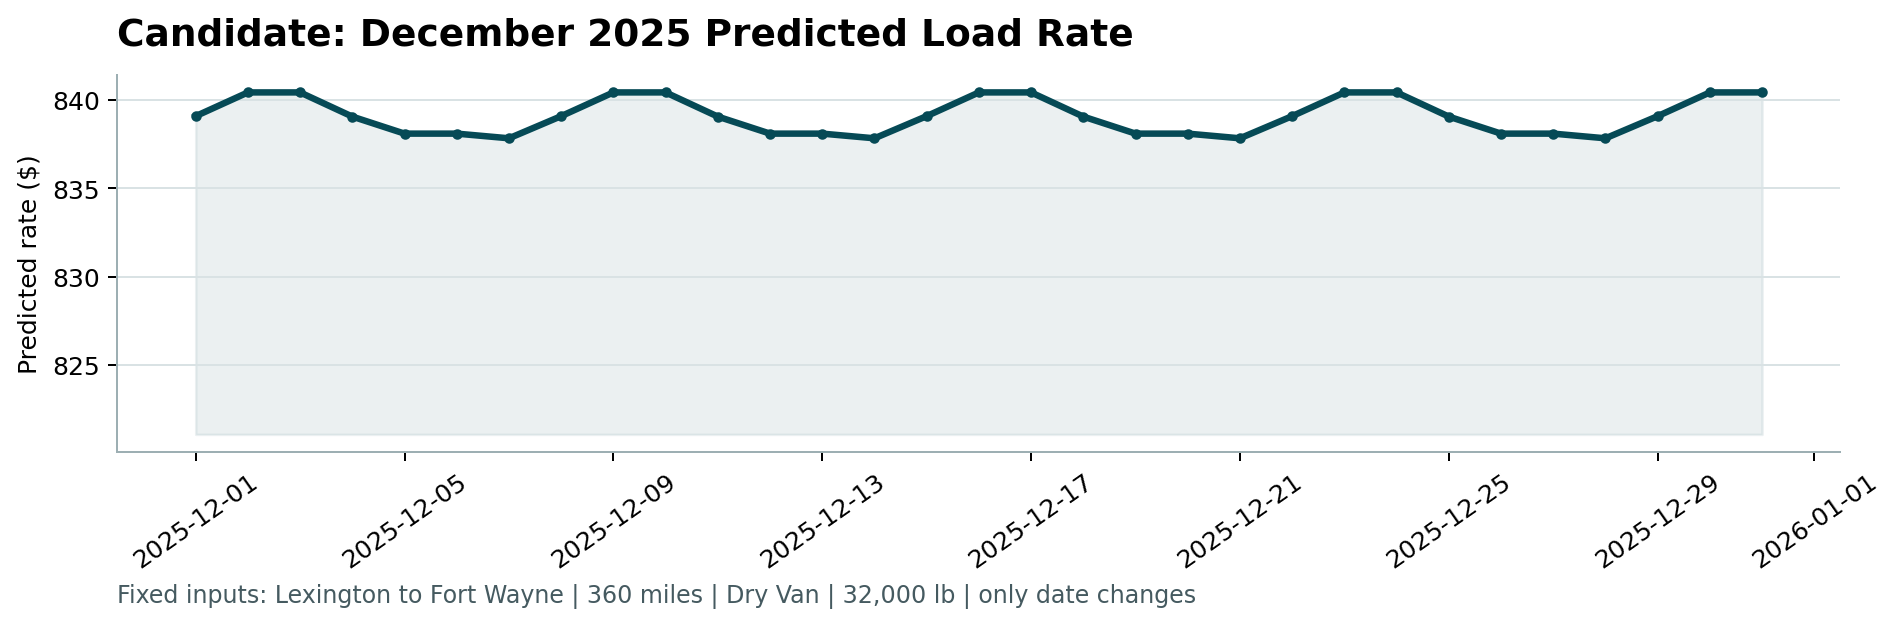

In [107]:
from IPython.display import Image, display

display(Image("scorer_results/candidate_december.png"))